# Zwierlein lab setup

```bash
conda env create -f environment.yml
conda activate atommovr_env

# With hardware connected including the GPU
pip install -r requirements-cuda.txt
```


In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_REPO = Path.cwd()
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from atommovr.utils.core import Configurations, PhysicalParams
from atommovr.utils.errormodels import UniformVacuumTweezerError, ZeroNoise
from atommovr.utils.timing import all_phase_duration_s, travel_duration_s
from awg_controller.scripts.atommovr_controller import (
    HardwareConfig,
    SoftwareConfig,
    atommovrController,
)
from awg_controller.src.awg_control import AODSettings, RFConverter
from awg_controller.src.camera import (
    Camera,
    GaussianCameraConfig,
    OfflineArrayCamera,
    RealArrayCamera,
)
from awg_controller.src.dds_strategies import STRATEGY_REGISTRY, get_strategy
from awg_controller.src.session_recorder import (
    GifOptions,
    SessionRecorder,
    SpectrogramOptions,
)

# Shared lattice (2-ch DDS: <=16 rows × <=5 cols) (multi DDS card expansion in progress)
ROWS, COLS = 14, 14

print(f"Camera ABC subclasses: {[c.__name__ for c in Camera.__subclasses__()]}")
print(f"lattice = {ROWS}×{COLS}")

Camera ABC subclasses: ['RealArrayCamera', 'OfflineArrayCamera']
lattice = 14×14


## 1. Camera

Allied Vision Alvium 1800 U-052: 816×624, 8-bit mono
pixel lattice spacing: `image_shape` + `min_spacing_px`
physical trap spacing: `PhysicalParams.spacing`

Both `OfflineArrayCamera` and `RealArrayCamera` inherit `Camera.detect_occupancy` (blob -> rotate -> `fit_grid_and_assign`). Stage dumps happen when the controller calls `camera.sync(array)`


frame shape=(624, 816), dtype=uint8, max=205
occupancy (truth) = 119 / 196, detected = 119


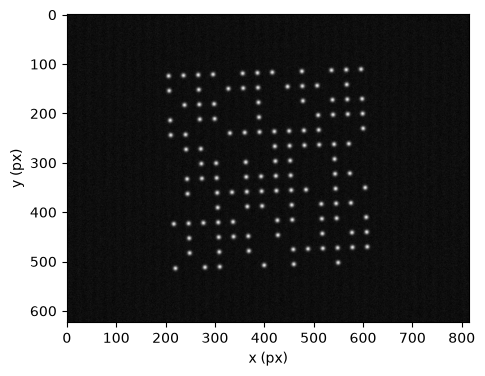

In [ ]:
# Gaussian image configuration
lab_camera = GaussianCameraConfig(
    image_shape=(624, 816),  # (H, W)
    sigma_px=3,
    peak_counts=180.0,
    background=12.0,  # residual scatter to minimize optically
    noise_level=5,
    stripe_intensity=1,
    spacing_x=30,  # px
    spacing_y=30,  # px
    angle=2,  # camera angle
    dtype=np.uint8,  # 8-bit mono
)

# Fake atom array generation and simulation
offline_preview = OfflineArrayCamera(
    (ROWS, COLS),
    image_generator=lab_camera,
    physical_params=PhysicalParams(loading_prob=0.6, spacing=18.07e-6),
    seed=42,
)

frame = offline_preview.acquire()
occ_det = offline_preview.detect_occupancy(frame)
print(f"frame shape={frame.shape}, dtype={frame.dtype}, max={frame.max()}")
print(
    f"occupancy (truth) = {offline_preview.occupancy.sum()} / {ROWS * COLS}, "
    f"detected = {int(occ_det.sum())}"
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(frame, cmap="gray", origin="upper")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
plt.show()

## 2. Error-model / timing

These must be measured on the apparatus.

Timing split (`atommovr.utils.timing`):

- Travel — Chebyshev sites x spacing / `AOD_speed` -> AWG TIMER / host waits
- Phases — pickup / accel / decel / putdown on the `ErrorModel` -> sim `evolution_time` only


In [ ]:
# Only used for simulation mode (synced with OfflineArrayCamera)
lab_error = UniformVacuumTweezerError(
    pickup_time=1e-6,
    putdown_time=1e-6,
    accel_time=1e-6,
    decel_time=1e-6,
    pickup_fail_rate=0.01,
    putdown_fail_rate=0.01,
    lifetime=5e3,
    seed=0,
)

lab_params = PhysicalParams(
    spacing=18.07e-6,  # m
    AOD_speed=6,  # µm/µs m/s
    loading_prob=0.65,  # enough atoms for a middle target
    middle_size=[10, 10],  # must fit inside ROWS x COLS
)


class _FakeMove:
    def __init__(self, fr, fc, tr, tc):
        self.from_row, self.from_col, self.to_row, self.to_col = fr, fc, tr, tc


travel_s = travel_duration_s(
    [_FakeMove(0, 0, 3, 2)], lab_params.spacing, lab_params.AOD_speed
)
phase_s = all_phase_duration_s(lab_error)

print(lab_error)
print(
    f"travel (3x2 Chebyshev) = {travel_s * 1e6:.1f}µs; all phases = {phase_s * 1e6:.1f}µs"
)

UniformVacuumTweezerError
travel (3x2 Chebyshev) = 9.0µs; all phases = 4.0µs


## 3. AOD frequency presets

1. Imaging: pixels -> grid indices (`Camera.detect_occupancy`)
2. RF: those indices -> Hz via `f = f_min + i * (f_max - f_min) / (n - 1)`


lattice = 14x14
Δf_v = 2.769 MHz/site (bandwidth 36.0 MHz)
Δf_h = 2.769 MHz/site (bandwidth 36.0 MHz)


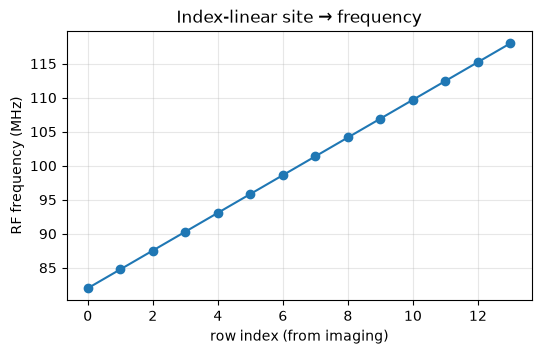

In [7]:
# Full grid size is based on AOD settings
aod = AODSettings(
    grid_rows=ROWS,
    grid_cols=COLS,
    f_min_v=82e6,
    f_max_v=118e6,
    f_min_h=82e6,
    f_max_h=118e6,
    alignment="center",
)
assert (aod.grid_rows, aod.grid_cols) == (ROWS, COLS)
# aod.validate_core_limits()  # settings-level DDS core check (not implemented properly yet)

bw_v_mhz = (aod.f_max_v - aod.f_min_v) / 1e6
bw_h_mhz = (aod.f_max_h - aod.f_min_h) / 1e6
print(f"lattice = {aod.grid_rows}x{aod.grid_cols}")
print(f"Δf_v = {aod.f_spacing_v / 1e6:.3f} MHz/site (bandwidth {bw_v_mhz:.1f} MHz)")
print(f"Δf_h = {aod.f_spacing_h / 1e6:.3f} MHz/site (bandwidth {bw_h_mhz:.1f} MHz)")

rf = RFConverter(aod, lab_params)
row_idx = np.arange(aod.grid_rows)
freqs = [rf._row_to_freq(i) for i in row_idx]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(row_idx, np.asarray(freqs) / 1e6, "o-")
ax.set_xlabel("row index (from imaging)")
ax.set_ylabel("RF frequency (MHz)")
ax.set_title("Index-linear site → frequency")
ax.grid(True, alpha=0.3)
plt.show()

## 4. Optics note

Theoretical slope: $dx/df = f_\mathrm{obj}\,(f_1/f_2)\,(\lambda/v)$.

Keep the measured `um_per_mhz` here for lab notes. `AODSettings.um_per_mhz` / `fov_um_*` are FOV helpers only.


In [8]:
wavelength_m, v_acoustic = 808e-9, 650.0
f1_mm, f2_mm, f_obj_mm = 75.0, 400.0, 28.0
um_per_mhz = (
    (f_obj_mm * 1e-3) * (f1_mm / f2_mm) * (wavelength_m / v_acoustic) * 1e12
)  # m/Hz -> µm/MHz
aod_bandwidth_mhz = 36.0
fov_um = um_per_mhz * aod_bandwidth_mhz

print(f"um_per_mhz = {um_per_mhz:.3f}")
print(
    f"FOV = {fov_um:.1f} µm over {aod_bandwidth_mhz:.0f} MHz (fov_um_v={aod.fov_um_v:.1f})"
)
print(
    f"theoretical spacing_x = {fov_um/(aod.grid_cols-1):.2f} µm, spacing_y = {fov_um/(aod.grid_rows-1):.2f} µm"
)

aod.um_per_mhz = um_per_mhz
lab_params.spacing = fov_um / (aod.grid_cols - 1) * 1e-6

um_per_mhz = 6.526
FOV = 234.9 µm over 36 MHz (fov_um_v=234.9)
theoretical spacing_x = 18.07 µm, spacing_y = 18.07 µm


## 5. Offline test

Uses `atommovrController(camera=offline_cam, recorder=…)`.

- Each round: `camera.sync(array, recorder=ctrl.recorder)` → `round_XX_acquire/` + `round_XX_detect/`
- Move / RF stats append to `rounds.jsonl`
- Optional GIFs via `GifOptions` → `frames.gif` / `occupancy.gif` (controller calls `finalize()` at end of `run()`)
- Optional per-round AWG-output spectrograms via `SpectrogramOptions` → `round_XX_spectrogram/spectrogram.png` (+ raw `.npy` waveforms), synthesized from that round's `AWGBatch` ramps
- Artifacts under `runs/run_YYYYMMDD_HHMMSS/`. Omit `recorder=` to disable; use `gif=GifOptions(enabled=False)` / `spectrogram=SpectrogramOptions(enabled=False)` to trim outputs

Pick an algorithm + target pattern in the cell below

In [9]:
from atommovr.utils.core import Configurations

ALGORITHM_NAME = "Hungarian"
# ALGORITHM_NAME options: "PCFA", "Hungarian", "Tetris", "BalanceAndCompact",
#                          "BCv2", "ParallelLBAP", "ParallelHungarian", "GeneralizedBalance"

TARGET_TYPE = Configurations.MIDDLE_FILL
# TARGET_TYPE options: Configurations.MIDDLE_FILL, .ZEBRA_HORIZONTAL, .ZEBRA_VERTICAL,
#                       .CHECKERBOARD, .Left_Sweep, .RANDOM

print(f"algorithm = {ALGORITHM_NAME!r}")
print(f"target pattern = {TARGET_TYPE.name}")

algorithm = 'Hungarian'
target pattern = MIDDLE_FILL


In [ ]:
grid = (aod.grid_rows, aod.grid_cols)

# For data storage
recorder = SessionRecorder(
    "runs",
    meta={
        "grid": list(grid),
        "target": list(lab_params.middle_size),
        "algo": ALGORITHM_NAME,
        "seed": 0,
        "note": "Offline test",
    },
    gif=GifOptions(
        enabled=True,
        sources=("frame", "occupancy"),
        stages=("detect",),  # only post-detection frames in the GIF
        duration_s=1,
        loop=0,
        max_side=512,
        occupancy_cell_px=16,
        auto_write=True,
    ),
    spectrogram=SpectrogramOptions(
        enabled=True,
        ramp_shape=aod.ramp_shape,  # keep in sync with the active backend's ramp shape
        channel_labels={0: "V/row", 1: "H/col"},
    ),
)

offline_cam = OfflineArrayCamera(
    grid,
    image_generator=lab_camera,
    physical_params=lab_params,
    seed=0,
)

# Information needed for algorithm run
sw = SoftwareConfig(
    algorithm_name=ALGORITHM_NAME,
    max_rounds=5,
    target_type=TARGET_TYPE,
    physical_params=lab_params,
    error_model=lab_error,  # Only needed for simulation mode
    aod_settings=aod,
)

# AWG settings
hw = HardwareConfig(max_amplitude_v=1.6)  # sim

print(f"session artifacts -> {recorder.run_dir}")

with atommovrController(sw, hw, camera=offline_cam, recorder=recorder) as ctrl:
    assert ctrl.camera is offline_cam
    assert ctrl.recorder is recorder
    assert ctrl.grid_shape == grid
    ok = ctrl.run()
    mask = (ctrl.array.target[:, :, 0] > 0).astype(int)
    occ = offline_cam.occupancy

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(mask, cmap="Blues", origin="upper", vmin=0, vmax=1)
axes[0].set_title(f"Target ({TARGET_TYPE.name})")
if occ is not None:
    axes[1].imshow(occ, cmap="Blues", origin="upper")
    filled = int((occ * mask).sum())
    axes[1].set_title(f"Final occ ({filled}/{int(mask.sum())} target sites)")
    print(
        f"success={ok}, atoms={int(occ.sum())}/{occ.size}, "
        f"target_filled={filled}/{int(mask.sum())}"
    )
else:
    print(f"success={ok}")
print(f"rounds.jsonl → {recorder.run_dir / 'rounds.jsonl'}")
print(f"frames.gif → {recorder.run_dir / 'frames.gif'}")
print(f"occupancy.gif → {recorder.run_dir / 'occupancy.gif'}")
plt.tight_layout()
plt.show()

# Per-round AWG output spectrograms (round_XX_spectrogram/spectrogram.png), one
# per round with moves — show the most recent one as a sanity check.
spec_dirs = sorted(recorder.run_dir.glob("round_*_spectrogram"))
print(
    f"spectrograms ({len(spec_dirs)} round(s)) → "
    f"{recorder.run_dir}/round_XX_spectrogram/spectrogram.png"
)
if spec_dirs:
    spec_img = plt.imread(spec_dirs[-1] / "spectrogram.png")
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.imshow(spec_img)
    ax2.axis("off")
    ax2.set_title(f"AWG output spectrogram — {spec_dirs[-1].name}")
    plt.show()

## 6. Hardware control (self-contained)

End-to-end on the apparatus:

```text
Alvium (or OfflineArrayCamera)
        │ acquire()
        ▼
Camera.detect_occupancy  ->  occupancy grid
        │
        ▼
Algorithm (Hungarian / ...)  ->  move batches
        │
        ▼
RFConverter  ->  AWGBatch (RFRamp list)
        │
        ▼
ScappFeeder (backend="scapp", default)  |  DDS strategy (backend="legacy_dds", opt-in)
        │  spcm.SCAPPTransfer + GPU         │  spcm DDS API
        ▼
Spectrum AWG  →  AOD RF
```

Safety (do this before connecting the AOD amp):

- `HardwareConfig.max_amplitude_v` must stay <= 2.0 V (default 1.6 V). Start at 1.0 V and check on a scope.
- `scapp` (default) needs `spcm` **and** `cupy`/CUDA to touch real hardware; missing either runs this cell in simulation. No fixed tone-count ceiling — `AODSettings.ramp_shape` picks `"linear"` or `"scurve"`.
- `legacy_dds` (`backend="legacy_dds"`) is still capacity-limited: `AODSettings.validate_core_limits()` / `validate_hardware_limits(grid_rows, grid_cols)`.

Pass a `Camera` via `camera=` (`OfflineArrayCamera` offline, `RealArrayCamera` on the lab). Pass `recorder=` on the controller for stage dumps + round JSONL + optional per-round AWG-output spectrograms (this section builds its own `recorder`, so its `SpectrogramOptions.ramp_shape` is set from this section's own `aod.ramp_shape` below).

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_REPO = Path.cwd()
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from atommovr.utils.core import Configurations, PhysicalParams
from atommovr.utils.errormodels import UniformVacuumTweezerError, ZeroNoise
from atommovr.utils.timing import all_phase_duration_s, travel_duration_s
from awg_controller.scripts.atommovr_controller import (
    HardwareConfig,
    SoftwareConfig,
    atommovrController,
)
from awg_controller.src.awg_control import AODSettings, RFConverter
from awg_controller.src.camera import (
    Camera,
    GaussianCameraConfig,
    OfflineArrayCamera,
    RealArrayCamera,
)
from awg_controller.src.dds_strategies import STRATEGY_REGISTRY, get_strategy
from awg_controller.src.session_recorder import (
    GifOptions,
    SessionRecorder,
    SpectrogramOptions,
)

In [ ]:
ROWS, COLS = 14, 14

# AWG
hw = HardwareConfig(
    card_path="/dev/spcm0",  # macOS/Linux device node (single card)
    max_amplitude_v=1.0,  # start conservative; raise toward <=1.6 after scope check
    output_load_ohms=50.0,
)

# AOD
aod = AODSettings(
    grid_rows=ROWS,
    grid_cols=COLS,
    f_min_v=82e6,
    f_max_v=118e6,
    f_min_h=82e6,
    f_max_h=118e6,
    alignment="center",
    ramp_shape="scurve",
)


# Physical params
lab_params = PhysicalParams(
    spacing=18.07e-6,  # m
    AOD_speed=6,  # µm/µs m/s
    loading_prob=0.65,  # enough atoms for a middle target
    middle_size=[10, 10],  # must fit inside ROWS x COLS
)

# RF converter
rf = RFConverter(aod, lab_params)

# Algorithm
ALGORITHM_NAME = "Hungarian"
# ALGORITHM_NAME options: "PCFA", "Hungarian", "Tetris", "BalanceAndCompact",
#                          "BCv2", "ParallelLBAP", "ParallelHungarian", "GeneralizedBalance"

TARGET_TYPE = Configurations.MIDDLE_FILL
# TARGET_TYPE options: Configurations.MIDDLE_FILL, .ZEBRA_HORIZONTAL, .ZEBRA_VERTICAL,
#                       .CHECKERBOARD, .Left_Sweep, .RANDOM

sw = SoftwareConfig(
    physical_params=lab_params,
    aod_settings=aod,
    max_rounds=5,
    algorithm_name=ALGORITHM_NAME,
    target_type=TARGET_TYPE,
)

# Data
recorder = SessionRecorder(
    "runs",
    meta={
        "grid": [aod.grid_rows, aod.grid_cols],
        "target": list(lab_params.middle_size),
        "algo": ALGORITHM_NAME,
        "seed": 0,
        "note": "Test",
    },
    gif=GifOptions(
        enabled=True,
        sources=("frame", "occupancy"),
        stages=("detect",),  # only post-detection frames in the GIF
        duration_s=1,
        loop=0,
        max_side=512,
        occupancy_cell_px=16,
        auto_write=True,
    ),
    spectrogram=SpectrogramOptions(
        enabled=True,
        ramp_shape=aod.ramp_shape,  # keep in sync with the active backend's ramp shape
        channel_labels={0: "V/row", 1: "H/col"},
    ),
)

# Reset offline camera
offline_cam = OfflineArrayCamera(
    grid_shape=(aod.grid_rows, aod.grid_cols),
    image_generator=lab_camera,
    physical_params=lab_params,
    seed=0,
)


# Uncomment when using actual camera
# def alvium_grab() -> np.ndarray:
#     """Placeholder: return one mono frame from the lab camera."""
#     raise NotImplementedError("hook up the Alvium SDK here")


# def lab_camera_fn() -> np.ndarray:
#     """Callable for RealArrayCamera"""
#     try:
#         return alvium_grab()
#     except NotImplementedError:
#         return offline_cam.acquire()


# real_cam = RealArrayCamera((aod.grid_rows, aod.grid_cols), camera_fn=lab_camera_fn)
# frame_hw = real_cam.acquire()
# occ_hw = real_cam.detect_occupancy(frame_hw)
# print(f"RealArrayCamera frame={frame_hw.shape}, detected atoms={int(occ_hw.sum())}")

In [ ]:
with atommovrController(sw, hw, camera=offline_cam, recorder=recorder) as ctrl:
    print(
        "=" * 50 + "\n"
        f"controller ready: backend={ctrl.backend}, "
        f"algo={ctrl.algorithm.__class__.__name__}, "
        f"camera={type(ctrl.camera).__name__}, "
        f"recorder={'on' if ctrl.recorder else 'off'}, "
        f"RF grid={ctrl.rf_converter.settings.grid_rows}×{ctrl.rf_converter.settings.grid_cols}"
        "\n" + "=" * 50
    )
    ok = ctrl.run()

print(
    "=" * 50 + "\n"
    f"run finished: success={ok}",
    "\n" + "=" * 50
)

# Per-round AWG output spectrograms (round_XX_spectrogram/spectrogram.png) — show
# the most recent one as a sanity check.
spec_dirs = sorted(recorder.run_dir.glob("round_*_spectrogram"))
if spec_dirs:
    print(f"spectrogram (per round) → {spec_dirs[-1] / 'spectrogram.png'}")
    spec_img = plt.imread(spec_dirs[-1] / "spectrogram.png")
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.imshow(spec_img)
    ax2.axis("off")
    ax2.set_title(f"AWG output spectrogram — {spec_dirs[-1].name}")
    plt.show()

# legacy_dds opt-in:
# with atommovrController(sw, hw, camera=real_cam_ctrl, recorder=recorder,
#                          backend="legacy_dds",
#                          strategy=get_strategy("ramp", use_scurve=True)) as ctrl:
#     ok = ctrl.run()

In [40]:
import json as _json

_rounds = recorder.run_dir / "rounds.jsonl"
if _rounds.is_file():
    _rows = [_json.loads(l) for l in _rounds.read_text().splitlines() if l.strip()]
    _move_rows = [r for r in _rows if r.get("n_moves", 0) > 0]
    for i,_move_row in enumerate(_move_rows):
        print(
            f"{i+1}-round: n_moves={_move_rows[-1]['n_moves']}, "
            f"rf_batches={_move_rows[-1].get('n_rf_batches')}, "
            f"rf_duration_s={_move_rows[-1].get('rf_duration_s')}"
        )
        print(f"  moves sample: {_move_rows[-1].get('moves', [])[:4]}")

1-round: n_moves=72, rf_batches=72, rf_duration_s=0.00021684000000000002
  moves sample: [{'fr': 0, 'fc': 4, 'tr': 1, 'tc': 4}, {'fr': 1, 'fc': 4, 'tr': 2, 'tc': 4}, {'fr': 1, 'fc': 8, 'tr': 2, 'tc': 7}, {'fr': 2, 'fc': 4, 'tr': 3, 'tc': 4}]


### CLI

With `spcm` + `cupy`/CUDA installed and the card present (`scapp`, default):

```bash
python awg_controller/scripts/atommover_controller.py \
  --algorithm Hungarian \
  --grid-rows 14 --grid-cols 14 \
  --target-rows 10 --target-cols 10 \
  --f-min-v 82e6 --f-max-v 118e6 \
  --f-min-h 82e6 --f-max-h 118e6 \
  --ramp-shape scurve \
  --card /dev/spcm0
```

`legacy_dds` (opt-in): add `--backend legacy_dds --strategy ramp --trg-timer 0.000050`.
